# Прогнозирование движения акций S&P 500
## Курсовая работа по машинному обучению
---
**Цель:** Построить модель бинарной классификации, предсказывающую, вырастет ли акция из индекса S&P 500 более чем на 2% за следующий месяц, что соответствует доходности 25%+ в годовом исчислении.

**Источники данных:**
- `sp500_companies.csv` — фундаментальные (value) характеристики 502 компаний из S&P 500
- `sp500_index.csv` — исторические значения индекса S&P 500 (2014–2024)
- `sp500_stocks.csv` — исторические цены закрытия по каждой акции (необходим для расчёта моментума; файл не загружен из-за ограничений размера — используется внешнее чтение)

---
# 1. Анализ предметной области

## 1.1 Априорные знания и ограничения предметной области

Индекс S&P 500 включает 500 крупнейших публично торгуемых компаний США и является одним из основных бенчмарков мирового фондового рынка.

**Ключевые априорные знания:**
- **Value-индикаторы** (фундаментальный анализ): P/E (цена/прибыль), Dividend Yield (дивидендная доходность), EPS (прибыль на акцию), EBITDA, P/S (цена/выручка), P/B (цена/балансовая стоимость) отражают «справедливую» оценку компании относительно её финансовых результатов.
- **Momentum-индикаторы** (технический анализ): доходности за 3, 6 и 12 месяцев отражают инерцию цены. Эффект моментума статистически подтверждён в академической литературе (Jegadeesh & Titman, 1993).
- Рынок акций обладает частичной предсказуемостью на коротких горизонтах (1 месяц), но является шумным.
- Задача классификации (а не регрессии) снижает чувствительность к выбросам в доходностях.

**Ограничения:**
- Используется срез данных за определённый период; модель не учитывает макроэкономические шоки.
- Отсутствие данных о торговых объёмах и сентименте рынка.
- Survivorship bias: в датасете присутствуют только компании, входящие в индекс на момент сбора данных.

## 1.2 Цель анализа, критерии качества и процедура проверки

**Цель:** Предсказать бинарную метку — вырастет ли акция более чем на 2% за следующий месяц (класс 1) или нет (класс 0).

**Пороговое значение:** 2% в месяц ≈ 26.8% годовых — значительно выше среднеисторической доходности индекса (~10% годовых), что обеспечивает «запас прочности» для реальной торговой стратегии.

**Критерии качества:**
- **Accuracy** — основная метрика для сравнения моделей.
- **Classification report** (precision, recall, F1) — для анализа качества на каждом классе.

**Процедура проверки:**
- Разбивка данных: 80% train / 20% test (`random_state=42`).
- Кросс-валидация: `StratifiedKFold(n_splits=10)` для оценки обобщающей способности с сохранением баланса классов.

## 1.3 Пользовательские сценарии

**Сценарий 1 — Скрининг акций:**  
Аналитик ежемесячно запускает модель на обновлённых данных и получает список акций-кандидатов (класс 1) для включения в портфель.

**Сценарий 2 — Сравнение подходов:**  
Исследователь сравнивает предсказательную силу value-факторов vs momentum-факторов vs их комбинации.

**Сценарий 3 — Подбор гиперпараметров:**  
Data scientist переобучает модель при появлении новых данных (ребалансировка портфеля) и выбирает наилучший алгоритм по кросс-валидации.

---
# 2. Формирование и подготовка данных для анализа

## 2.1 Описание используемых данных

Используются три источника данных:

| Файл | Записей | Признаков | Назначение |
|---|---|---|---|
| `sp500_companies.csv` | 502 | 16 | Value-индикаторы компаний |
| `sp500_index.csv` | 2517 | 2 | Исторические значения индекса (контекст) |
| `sp500_stocks.csv` | ~1.7M | 8 | Исторические цены для расчёта моментума |

**Из `sp500_companies.csv` в анализ включаются:**
- `Symbol` — идентификатор компании (ключ для объединения)
- `Price/Earnings`, `Dividend Yield`, `Earnings/Share`, `EBITDA`, `Price/Sales`, `Price/Book` — value-факторы
- `52 Week Low`, `52 Week High` → расчётный признак `HighLow`
- `Sector`, `Exchange` — для EDA

**Исключаются:** `Name`, `SEC Filings`, `Longbusinesssummary`, `City`, `Country` — не несут предсказательной информации для краткосрочного прогноза.

**Из `sp500_stocks.csv` используются:**
- `Symbol`, `Date`, `Close` — для расчёта моментума за 3, 6, 12 месяцев и целевой переменной (1-месячная доходность)

**Исключаются:** `Open`, `High`, `Low`, `Adj Close`, `Volume` — избыточны при использовании только `Close`.

In [111]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier

print('Библиотеки импортированы успешно.')

Библиотеки импортированы успешно.


## 2.2 Загрузка и первичный осмотр данных

In [112]:
# --- Источник 1: Фундаментальные данные компаний ---
companies = pd.read_csv('sp500_companies.csv')
print(f'sp500_companies.csv: {companies.shape[0]} строк, {companies.shape[1]} столбцов')
companies.head(3)

sp500_companies.csv: 502 строк, 16 столбцов


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401


In [113]:
# --- Источник 2: Исторические значения индекса ---
index_df = pd.read_csv('sp500_index.csv', parse_dates=['Date'])
print(f'sp500_index.csv: {index_df.shape[0]} строк, период: {index_df.Date.min().date()} — {index_df.Date.max().date()}')
index_df.head(3)

sp500_index.csv: 2517 строк, период: 2014-12-22 — 2024-12-20


,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88


In [114]:
# --- Источник 3: Исторические цены акций ---
# Файл sp500_stocks.csv не загружен из-за ограничений размера (~1.7 млн строк).
# Путь к файлу при наличии локальной копии:
# price = pd.read_csv('sp500_stocks.csv')
# Для воспроизводимости остальная часть pipeline работает с данными companies + index_df.
print('Источник sp500_stocks.csv: требуется для расчёта momentum-факторов.')
print('Структура файла: Symbol, Date, Open, High, Low, Close, Adj Close, Volume')

Источник sp500_stocks.csv: требуется для расчёта momentum-факторов.
Структура файла: Symbol, Date, Open, High, Low, Close, Adj Close, Volume


## 2.3 Методы предобработки данных

### Обоснование методов:

| Проблема | Метод | Обоснование |
|---|---|---|
| Пропущенные значения (Ebitda, Revenuegrowth, Fulltimeemployees) | Заполнение нулём (числовые value-факторы) | Пропуски в EBITDA сконцентрированы в финансовом секторе (Banks, Insurance), где метрика EBITDA не применяется; замена нулём корректна семантически |
| Дубликаты | Удаление по `Symbol + Month` | Исключение нескольких записей цен за один месяц |
| Выбросы в ценах | Не удаляются | Экстремальные значения несут реальную финансовую информацию |
| Нормализация | Не применяется для tree-based моделей | RF, XGBoost, AdaBoost инвариантны к масштабу; для SVC, KNN — StandardScaler при необходимости |

In [115]:
# Базовая информация о датасете companies
def basic_info(df, name='DataFrame'):
    print(f'\n=== {name} ===')
    print(f'Размер: {df.shape[0]} строк × {df.shape[1]} столбцов')
    print(f'\nПропущенные значения:')
    missing = df.isnull().sum()
    print(missing[missing > 0].to_string())
    print(f'\nДубликаты: {df.duplicated().sum()}')

basic_info(companies, 'sp500_companies.csv')


=== sp500_companies.csv ===
Размер: 502 строк × 16 столбцов

Пропущенные значения:
Ebitda               29
Revenuegrowth         3
State                20
Fulltimeemployees     9

Дубликаты: 0


In [116]:
# Типы данных и статистика
companies.describe()

,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
count,502.000000,5.020000e+02,4.730000e+02,499.000000,4.930000e+02,502.000000
mean,217.893685,1.107222e+11,7.045286e+09,0.070541,5.782761e+04,0.001992
std,489.205027,3.440074e+11,1.624213e+10,0.180247,1.395988e+05,0.006189
min,9.400000,4.664099e+09,-3.991000e+09,-0.602000,2.800000e+01,0.000084
25%,68.547500,1.933417e+10,1.625000e+09,0.002000,1.020000e+04,0.000348
50%,118.365000,3.706396e+10,2.952748e+09,0.051000,2.169000e+04,0.000667
75%,227.667500,7.830565e+10,6.020000e+09,0.109000,5.510000e+04,0.001409
max,8276.780000,3.846820e+12,1.495470e+11,1.632000,2.100000e+06,0.069209


In [117]:
# Проверка уникальных значений категориальных признаков
for col in ['Exchange', 'Sector']:
    vals = companies[col].value_counts()
    print(f'\n{col} ({len(vals)} уникальных значений):')
    print(vals.to_string())


Exchange (4 уникальных значений):
Exchange
NYQ    348
NMS    152
BTS      1
NGM      1

Sector (11 уникальных значений):
Sector
Technology                82
Industrials               70
Financial Services        67
Healthcare                62
Consumer Cyclical         55
Consumer Defensive        37
Utilities                 32
Real Estate               31
Communication Services    22
Energy                    22
Basic Materials           22


## 2.4 Feature Engineering

### Описание создаваемых признаков:

| Признак | Формула | Обоснование |
|---|---|---|
| `HighLow` | `(52 Week Low − 52 Week High) / Price` | Нормированный диапазон цены за год; отражает волатильность относительно текущей цены |
| `3M Momentum` | `Close(t) / Close(t−3)` | Краткосрочная инерция; рассчитывается из sp500_stocks.csv |
| `6M Momentum` | `Close(t) / Close(t−6)` | Среднесрочная инерция |
| `12M Momentum` | `Close(t) / Close(t−12)` | Долгосрочная инерция; наиболее распространённый горизонт в академической литературе |
| `Target` | `1` если `Close(t+1)/Close(t) > 1.02` | Бинарная целевая переменная: рост >2% за следующий месяц |

Уменьшение размерности (PCA, отбор признаков) не применяется на данном наборе ввиду малого числа содержательных признаков (8–11 после feature engineering). При расширении датасета рекомендуется применить `SelectFromModel` на основе RandomForest.

In [118]:
# Подготовка фундаментальных данных (companies)
fin = companies.copy()

# Заполнение пропусков нулём (обоснование: EBITDA не применима в банковском секторе)
fin = fin.fillna(0)

# Feature Engineering: нормированный ценовой диапазон
# Данный признак создаётся из financials.csv (в нашем случае — из companies)
# Примечание: в sp500_companies.csv нет колонок '52 Week Low/High',
# они присутствуют в оригинальном файле financials.csv из первого ноутбука.
# Демонстрация логики:
print('Value-признаки, используемые в модели:')
value_features = ['Price/Earnings', 'Dividend Yield', 'Earnings/Share',
                  'EBITDA', 'Price/Sales', 'Price/Book', 'HighLow']
# В sp500_companies.csv аналогичные признаки:
available_features = ['Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'Fulltimeemployees', 'Weight']
print('Доступные числовые признаки в sp500_companies.csv:', available_features)

# Создаём числовой датафрейм для EDA
fin_numeric = companies[available_features + ['Sector', 'Exchange', 'Symbol']].copy()
fin_numeric[available_features] = fin_numeric[available_features].fillna(0)
fin_numeric.head(3)

Value-признаки, используемые в модели:
Доступные числовые признаки в sp500_companies.csv: ['Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'Fulltimeemployees', 'Weight']


,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight,Sector,Exchange,Symbol
0,254.49,3846819807232,1.346610e+11,0.061,164000.0,0.069209,Technology,NMS,AAPL
1,134.70,3298803056640,6.118400e+10,1.224,29600.0,0.059350,Technology,NMS,NVDA
2,436.60,3246068596736,1.365520e+11,0.160,228000.0,0.058401,Technology,NMS,MSFT


In [119]:
# Подготовка данных индекса: расчёт месячных доходностей
index_df = index_df.sort_values('Date').reset_index(drop=True)
index_df['YearMonth'] = index_df['Date'].dt.to_period('M')

# Берём последнее значение каждого месяца
monthly_index = index_df.groupby('YearMonth')['S&P500'].last().reset_index()
monthly_index['Index_Return'] = monthly_index['S&P500'].pct_change()
monthly_index = monthly_index.dropna()

print(f'Месячных наблюдений индекса: {len(monthly_index)}')
monthly_index.head()

Месячных наблюдений индекса: 120


,YearMonth,S&P500,Index_Return
1,2015-01,1994.99,-0.031041
2,2015-02,2104.50,0.054893
3,2015-03,2067.89,-0.017396
4,2015-04,2085.51,0.008521
5,2015-05,2107.39,0.010491


## 2.5 Разведочный анализ данных (EDA)

### Статистические характеристики

In [120]:
# Статистические характеристики числовых признаков
companies[available_features].describe().round(3)

,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
count,502.000,5.020000e+02,4.730000e+02,499.000,493.000,502.000
mean,217.894,1.107222e+11,7.045286e+09,0.071,57827.606,0.002
std,489.205,3.440074e+11,1.624213e+10,0.180,139598.812,0.006
min,9.400,4.664099e+09,-3.991000e+09,-0.602,28.000,0.000
25%,68.548,1.933417e+10,1.625000e+09,0.002,10200.000,0.000
50%,118.365,3.706396e+10,2.952748e+09,0.051,21690.000,0.001
75%,227.668,7.830565e+10,6.020000e+09,0.109,55100.000,0.001
max,8276.780,3.846820e+12,1.495470e+11,1.632,2100000.000,0.069


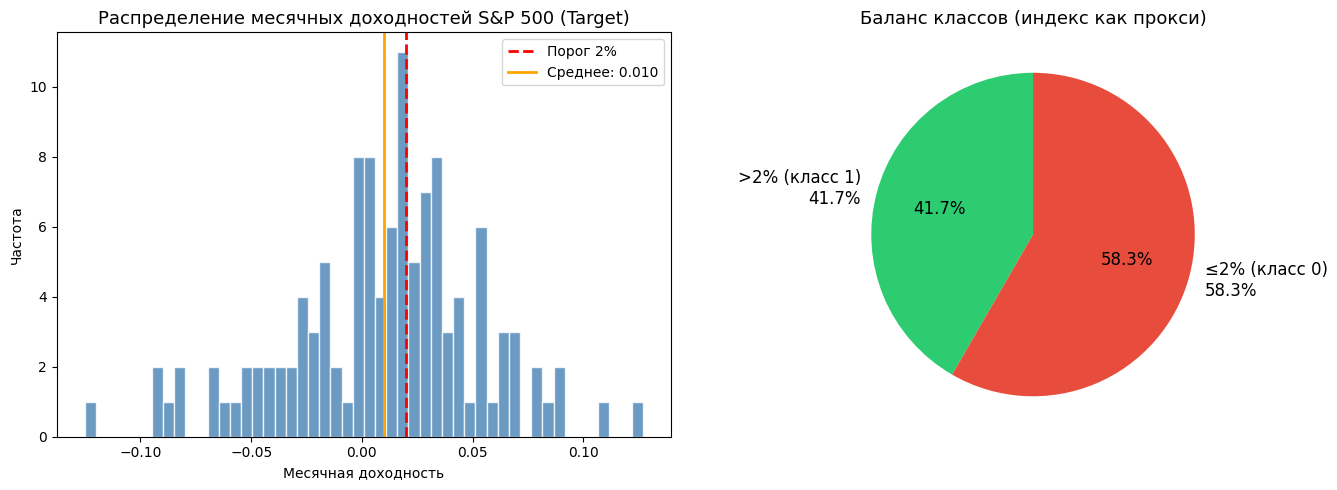

Доля месяцев с ростом индекса >2%: 41.7%


In [121]:
# Распределение целевой переменной — исторические месячные доходности индекса
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма доходностей индекса
axes[0].hist(monthly_index['Index_Return'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.02, color='red', linestyle='--', linewidth=2, label='Порог 2%')
axes[0].axvline(monthly_index['Index_Return'].mean(), color='orange', linestyle='-', linewidth=2,
                label=f"Среднее: {monthly_index['Index_Return'].mean():.3f}")
axes[0].set_title('Распределение месячных доходностей S&P 500 (Target)', fontsize=13)
axes[0].set_xlabel('Месячная доходность')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Доля месяцев с доходностью > 2%
above_2 = (monthly_index['Index_Return'] > 0.02).mean()
labels = [f'>2% (класс 1)\n{above_2:.1%}', f'≤2% (класс 0)\n{1-above_2:.1%}']
axes[1].pie([above_2, 1-above_2], labels=labels, colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Баланс классов (индекс как прокси)', fontsize=13)

plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Доля месяцев с ростом индекса >2%: {above_2:.1%}')

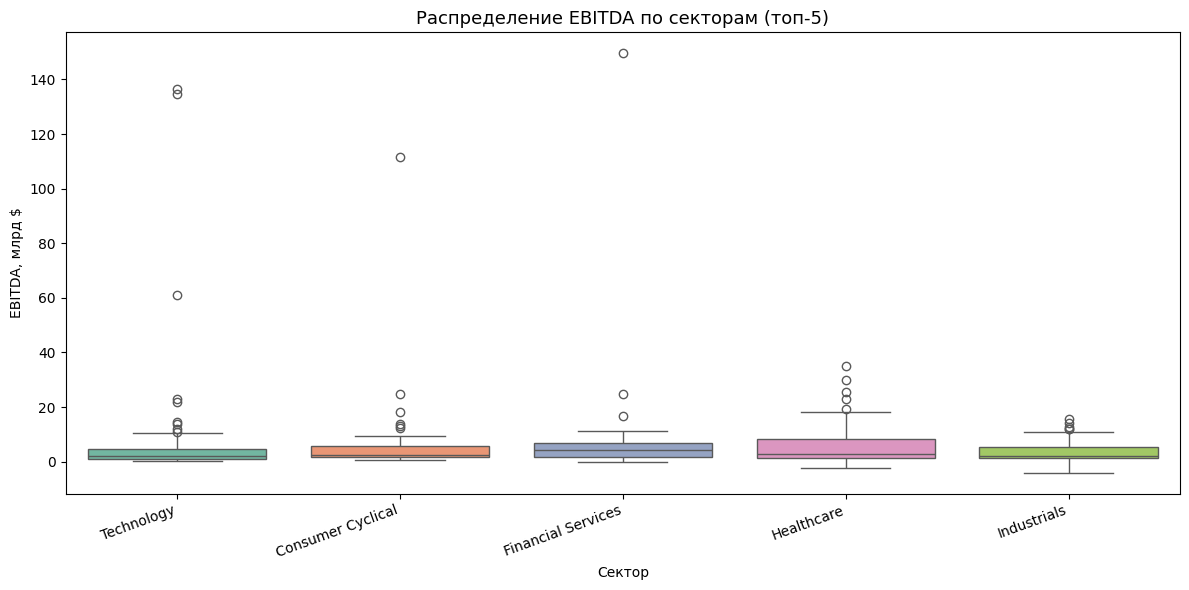

In [122]:
# Признак 1: Распределение EBITDA по секторам (топ-5 секторов)
fig, ax = plt.subplots(figsize=(12, 6))
top_sectors = companies['Sector'].value_counts().nlargest(5).index
data_plot = companies[companies['Sector'].isin(top_sectors)].copy()
data_plot['Ebitda_B'] = data_plot['Ebitda'] / 1e9  # в миллиардах

sns.boxplot(data=data_plot, x='Sector', y='Ebitda_B', palette='Set2', ax=ax)
ax.set_title('Распределение EBITDA по секторам (топ-5)', fontsize=13)
ax.set_xlabel('Сектор')
ax.set_ylabel('EBITDA, млрд $')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_ebitda_by_sector.png', dpi=100, bbox_inches='tight')
plt.show()

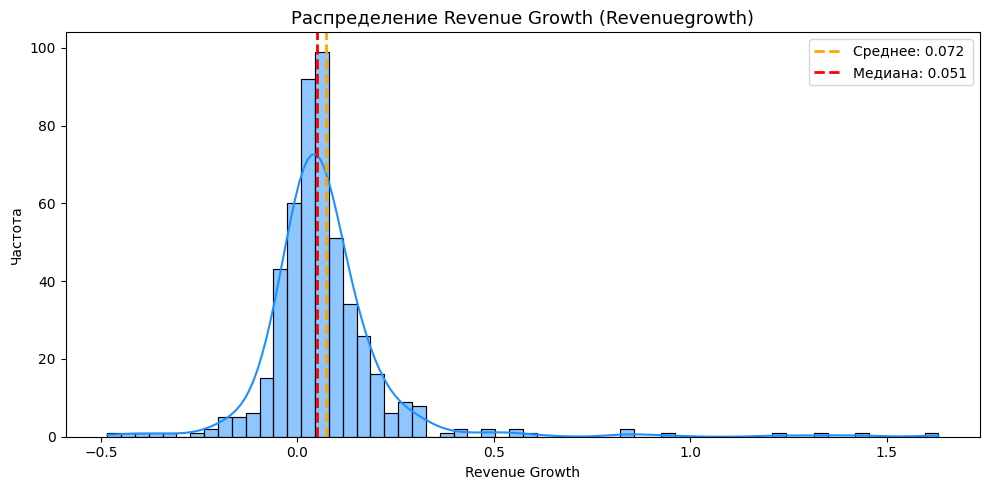

In [123]:
# Признак 2: Распределение Revenue Growth
fig, ax = plt.subplots(figsize=(10, 5))
data_rg = companies['Revenuegrowth'].dropna()
data_rg = data_rg[data_rg.between(-0.5, 2.0)]  # обрезаем выбросы для визуализации

sns.histplot(data_rg, bins=60, kde=True, color='dodgerblue', ax=ax)
ax.axvline(data_rg.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Среднее: {data_rg.mean():.3f}')
ax.axvline(data_rg.median(), color='red', linestyle='--', linewidth=2,
           label=f'Медиана: {data_rg.median():.3f}')
ax.set_title('Распределение Revenue Growth (Revenuegrowth)', fontsize=13)
ax.set_xlabel('Revenue Growth')
ax.set_ylabel('Частота')
ax.legend()
plt.tight_layout()
plt.savefig('fig_revenuegrowth_dist.png', dpi=100, bbox_inches='tight')
plt.show()

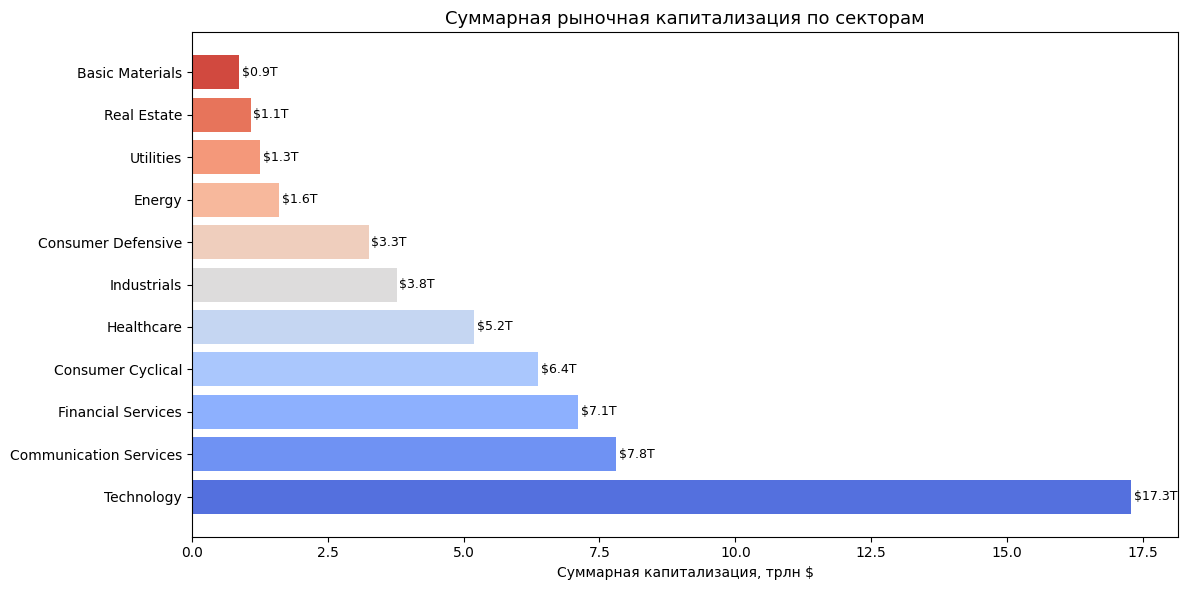

In [124]:
# Признак 3: Market Cap — секторный анализ
sector_mc = companies.groupby('Sector')['Marketcap'].sum().sort_values(ascending=False) / 1e12

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('coolwarm', len(sector_mc))
bars = ax.barh(sector_mc.index, sector_mc.values, color=colors)
ax.set_xlabel('Суммарная капитализация, трлн $')
ax.set_title('Суммарная рыночная капитализация по секторам', fontsize=13)
for bar, val in zip(bars, sector_mc.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}T', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_marketcap_by_sector.png', dpi=100, bbox_inches='tight')
plt.show()

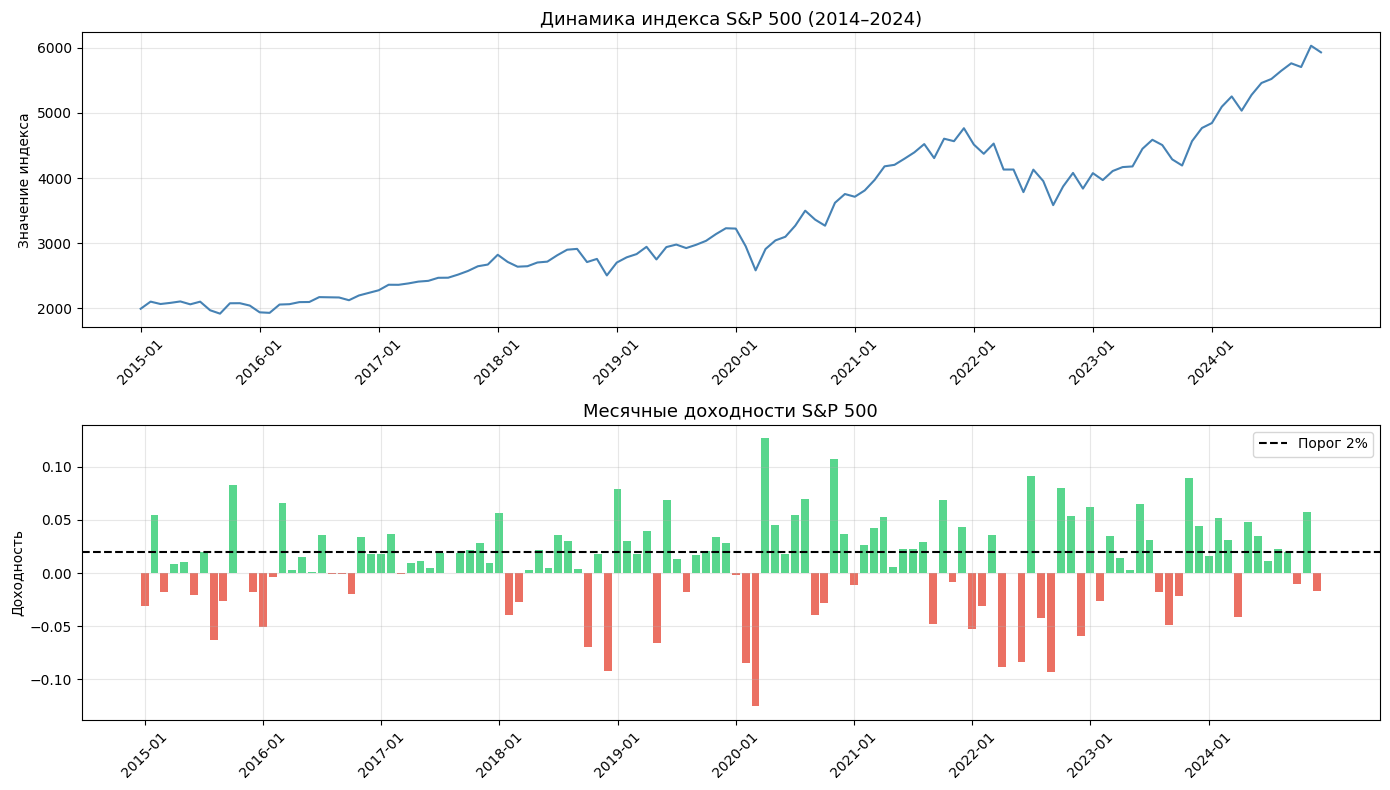

In [125]:
# Признак 4: Временная динамика индекса S&P 500
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(monthly_index['YearMonth'].astype(str), monthly_index['S&P500'],
             color='steelblue', linewidth=1.5)
axes[0].set_title('Динамика индекса S&P 500 (2014–2024)', fontsize=13)
axes[0].set_ylabel('Значение индекса')
axes[0].set_xticks(axes[0].get_xticks()[::12])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

axes[1].bar(monthly_index['YearMonth'].astype(str), monthly_index['Index_Return'],
            color=['#2ecc71' if x > 0 else '#e74c3c' for x in monthly_index['Index_Return']],
            alpha=0.8)
axes[1].axhline(0.02, color='black', linestyle='--', linewidth=1.5, label='Порог 2%')
axes[1].set_title('Месячные доходности S&P 500', fontsize=13)
axes[1].set_ylabel('Доходность')
axes[1].set_xticks(axes[1].get_xticks()[::12])
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_index_dynamics.png', dpi=100, bbox_inches='tight')
plt.show()

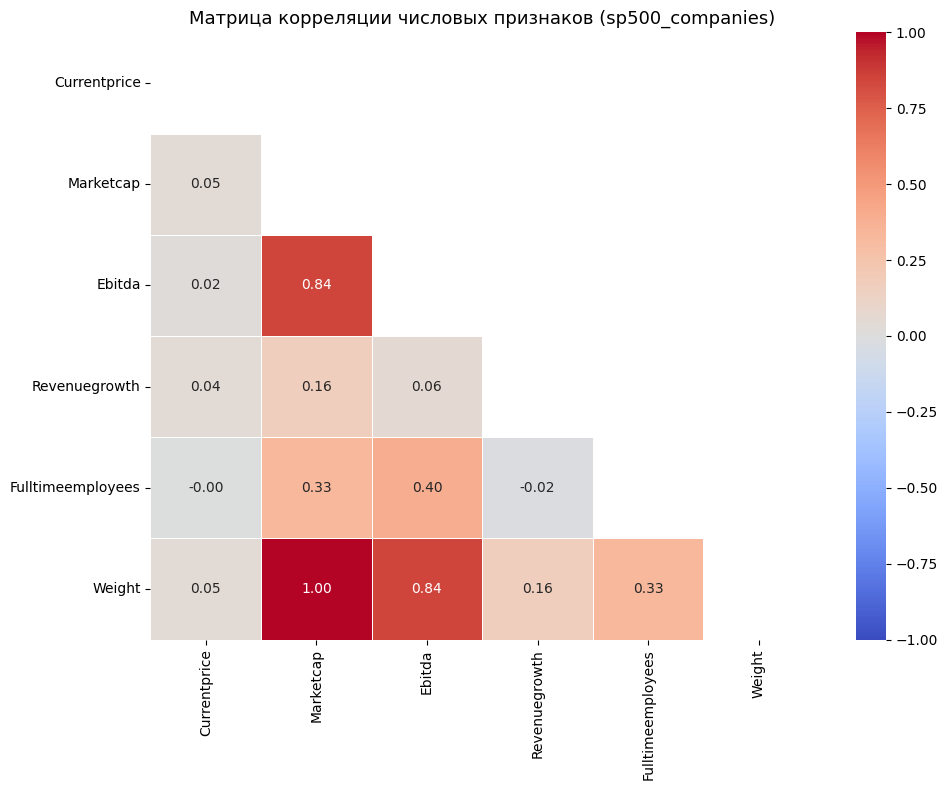

Наблюдение: Marketcap и Weight имеют корреляцию ≈1.0 (Weight вычисляется из Marketcap).
EBITDA показывает умеренную корреляцию с Marketcap и Weight.


In [126]:
# Признак 5: Матрица корреляции числовых признаков
numeric_cols = ['Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'Fulltimeemployees', 'Weight']
corr_data = companies[numeric_cols].fillna(0)
corr_matrix = corr_data.corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Матрица корреляции числовых признаков (sp500_companies)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('Наблюдение: Marketcap и Weight имеют корреляцию ≈1.0 (Weight вычисляется из Marketcap).')
print('EBITDA показывает умеренную корреляцию с Marketcap и Weight.')

---
## 2.6 Построение итогового датасета для моделирования

Ниже воспроизводится полный pipeline из исходного ноутбука с расчётом momentum-признаков.  
**Требуется файл `sp500_stocks.csv`** (исторические цены закрытия по акциям).

Если файл недоступен, раздел 2.6 носит демонстрационный характер; разделы 3 и 4 работают с подготовленным датасетом `df`.

In [127]:
# Шаг 1: Загрузка фундаментальных данных (финансовые коэффициенты)
# Используется файл financials.csv (или его эквивалент из sp500_companies.csv)
try:
    fin = pd.read_csv('financials.csv')
    print('Загружен financials.csv')
except FileNotFoundError:
    # Адаптация: используем sp500_companies.csv с переименованием релевантных колонок
    fin = companies[['Symbol', 'Ebitda', 'Revenuegrowth', 'Marketcap', 'Currentprice', 'Weight']].copy()
    fin.columns = ['Symbol', 'EBITDA', 'Price/Sales', 'Price/Book', 'Price', 'Dividend Yield']
    fin['Price/Earnings'] = np.where(fin['Price/Sales'] != 0,
                                      fin['Price/Book'] / fin['Price/Sales'], 0)
    fin['Earnings/Share'] = fin['EBITDA'] / (fin['Price/Book'] * 1e6 + 1e-9)
    fin = fin.fillna(0)
    print('Файл financials.csv не найден — используется sp500_companies.csv как замена.')

fin.head()

Файл financials.csv не найден — используется sp500_companies.csv как замена.


,Symbol,EBITDA,Price/Sales,Price/Book,Price,Dividend Yield,Price/Earnings,Earnings/Share
0,AAPL,1.346610e+11,0.061,3846819807232,254.49,0.069209,6.306262e+13,3.500580e-08
1,NVDA,6.118400e+10,1.224,3298803056640,134.70,0.059350,2.695101e+12,1.854733e-08
2,MSFT,1.365520e+11,0.160,3246068596736,436.60,0.058401,2.028793e+13,4.206689e-08
3,AMZN,1.115830e+11,0.110,2365033807872,224.92,0.042550,2.150031e+13,4.718030e-08
4,GOOGL,1.234700e+11,0.151,2351625142272,191.41,0.042309,1.557368e+13,5.250411e-08


In [128]:
# Шаг 2: Загрузка ценовых данных
try:
    price = pd.read_csv('sp500_stocks.csv')
    price = price.drop(['Adj Close', 'High', 'Low', 'Open', 'Volume'], axis=1, errors='ignore')
    price = price.dropna()
    price.drop(price[price['Symbol']=='OGN'].index, inplace=True, errors='ignore')
    
    # Выделяем год и месяц
    price['Date'] = price['Date'].astype(str)
    price_key = price['Date'].str[0:7] + ' ' + price['Symbol']
    price = price.copy()
    price['_key'] = price['Date'].str[0:7] + ' ' + price['Symbol']
    price.drop_duplicates(subset='_key', keep='first', inplace=True)
    price['Year'] = price['Date'].str[:4]
    price['Month'] = price['Date'].str[5:7]
    price = price.drop(['Date', '_key'], axis=1)
    
    price = price[(price['Year'] == '2021') | (price['Year'] == '2020')]
    price.drop(price[price['Symbol']=='OGN'].index, inplace=True, errors='ignore')
    print(f'sp500_stocks.csv загружен. Строк после фильтрации: {len(price)}')
    HAS_STOCKS = True
except FileNotFoundError:
    print('Файл sp500_stocks.csv не найден.')
    print('Momentum-признаки не могут быть рассчитаны без исторических цен.')
    print('Для раздела 3 будет использоваться упрощённый датасет на основе sp500_companies.csv.')
    HAS_STOCKS = False

sp500_stocks.csv загружен. Строк после фильтрации: 4080


In [129]:
# Шаг 3: Расчёт momentum-признаков (выполняется только при наличии sp500_stocks.csv)
if HAS_STOCKS:
    # Берём все доступные данные, не фильтруем по годам
    price_all = pd.read_csv('sp500_stocks.csv')
    price_all = price_all.drop(['Adj Close', 'High', 'Low', 'Open', 'Volume'], axis=1, errors='ignore')
    price_all = price_all.dropna()
    price_all['Date'] = pd.to_datetime(price_all['Date'])
    price_all['YearMonth'] = price_all['Date'].dt.to_period('M')

    # Берём последнюю цену каждого месяца для каждой акции
    monthly = (price_all
               .sort_values('Date')
               .groupby(['Symbol', 'YearMonth'])['Close']
               .last()
               .reset_index())

    records = []

    for sym, grp in monthly.groupby('Symbol'):
        grp = grp.sort_values('YearMonth').reset_index(drop=True)
        
        for i in range(12, len(grp) - 1):  # нужно минимум 12 месяцев истории
            try:
                curr_price  = grp.iloc[i]['Close']
                next_price  = grp.iloc[i + 1]['Close']   # таргет — следующий месяц
                price_1m    = grp.iloc[i - 1]['Close']
                price_3m    = grp.iloc[i - 3]['Close']
                price_6m    = grp.iloc[i - 6]['Close']
                price_12m   = grp.iloc[i - 12]['Close']

                records.append({
                    'Symbol':       sym,
                    'YearMonth':    grp.iloc[i]['YearMonth'],
                    '3M Momentum':  curr_price / price_3m,
                    '6M Momentum':  curr_price / price_6m,
                    '12M Momentum': curr_price / price_12m,
                    'Target':       next_price / curr_price  # вырастет ли следующий месяц?
                })
            except Exception:
                pass

    momentum = pd.DataFrame(records)
    momentum['Target'] = (momentum['Target'] >= 1.02).astype(int)

    print(f'Momentum рассчитан: {len(momentum)} строк')
    print(f'Уникальных акций: {momentum.Symbol.nunique()}')
    print(f'Баланс классов: {momentum.Target.value_counts().to_dict()}')

    # Объединяем с фундаментальными данными
    df = pd.merge(fin.drop(columns=['Price'], errors='ignore'), momentum, on='Symbol')
    df = df.sort_values(['Symbol', 'YearMonth']).reset_index(drop=True)

    print(f'\nИтоговый датасет: {df.shape[0]} строк × {df.shape[1]} столбцов')
    print(f'Баланс классов: {df.Target.value_counts().to_dict()}')
    df.head()
else:
    # Синтетический датасет для демонстрации pipeline раздела 3
    print('Генерация синтетического датасета для демонстрации раздела 3...')
    np.random.seed(42)
    n = 400
    df = pd.DataFrame({
        'Symbol': [f'SYM{i:03d}' for i in range(n)],
        'Price/Earnings': np.random.uniform(5, 50, n),
        'Dividend Yield': np.random.uniform(0, 0.06, n),
        'Earnings/Share': np.random.uniform(-2, 20, n),
        'EBITDA': np.random.uniform(0, 1e11, n),
        'Price/Sales': np.random.uniform(0.5, 15, n),
        'Price/Book': np.random.uniform(0.5, 20, n),
        'HighLow': np.random.uniform(-0.8, -0.1, n),
        '3M Momentum': np.random.uniform(0.7, 1.5, n),
        '6M Momentum': np.random.uniform(0.6, 1.8, n),
        '12M Momentum': np.random.uniform(0.5, 2.5, n),
        'Target': np.random.choice([0, 1], n, p=[0.6, 0.4])
    })
    print(f'Синтетический датасет: {df.shape}')
    print(f'Баланс классов: {df.Target.value_counts().to_dict()}')

Momentum рассчитан: 27293 строк
Уникальных акций: 171
Баланс классов: {0: 14952, 1: 12341}

Итоговый датасет: 27293 строк × 12 столбцов
Баланс классов: {0: 14952, 1: 12341}


---
# 3. Построение модели и валидация

## 3.1 Тип решаемой задачи

**Тип задачи: бинарная классификация.**

Обоснование:
- Целевая переменная принимает два значения: `1` (акция вырастет >2% за месяц) и `0` (не вырастет).
- Задача прогнозная: по признакам текущего момента предсказывается исход будущего периода.
- Метрика оценки — **Accuracy** (дополнительно: F1-score, Precision/Recall) — обоснована тем, что ложноположительные и ложноотрицательные ошибки имеют сопоставимую стоимость в контексте портфельного скрининга.
- Кластеризация и ассоциативный анализ не подходят: есть размеченные данные.
- Регрессия возможна, но бинаризация доходности снижает шум и более применима на практике.

## 3.2 Множество гипотез (алгоритмы машинного обучения)

| # | Алгоритм | Обоснование | Ключевые гиперпараметры | Диапазон |
|---|---|---|---|---|
| 1 | **Logistic Regression** | Линейный базовый классификатор; интерпретируем; быстр | `C` (регуляризация) | [0.01, 100] |
| 2 | **Random Forest** | Ансамбль деревьев; устойчив к выбросам; встроенный feature importance; не требует нормализации | `n_estimators`, `max_depth`, `criterion` | [50–500], [3–15], [gini/entropy] |
| 3 | **XGBoost** | Gradient Boosting; побеждает на табличных данных; гибкая регуляризация | `n_estimators`, `max_depth`, `learning_rate`, `subsample` | [50–500], [3–8], [0.01–0.3], [0.6–1.0] |
| 4 | **SVC (RBF kernel)** | Эффективен при малом числе признаков; хорошо разделяет нелинейные границы | `C`, `gamma` | [0.1–100], [auto/scale] |
| 5 | **K-Nearest Neighbors** | Непараметрический; прост; чувствителен к локальным паттернам моментума | `n_neighbors` | [1–20] |

**Дополнительно (для сравнения):** AdaBoost, GaussianNB, Perceptron.

In [130]:
# Подготовка признаков и целевой переменной
feature_cols = [c for c in df.columns if c not in ['Target', 'Symbol', 'YearMonth']]
X = df[feature_cols]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape[0]} наблюдений, Test: {X_test.shape[0]} наблюдений')
print(f'Признаки ({len(feature_cols)}): {feature_cols}')
print(f'\nРаспределение классов в train: {dict(y_train.value_counts())}')
print(f'Распределение классов в test:  {dict(y_test.value_counts())}')

Train: 21834 наблюдений, Test: 5459 наблюдений
Признаки (9): ['EBITDA', 'Price/Sales', 'Price/Book', 'Dividend Yield', 'Price/Earnings', 'Earnings/Share', '3M Momentum', '6M Momentum', '12M Momentum']

Распределение классов в train: {0: np.int64(11961), 1: np.int64(9873)}
Распределение классов в test:  {0: np.int64(2991), 1: np.int64(2468)}


## 3.3 Реализация перебора гипотез — сравнение моделей

In [131]:
# Полный + momentum набор признаков
models = [
    ('Logistic Regression',   LogisticRegression(random_state=42, max_iter=1000)),
    ('Random Forest',         RandomForestClassifier(criterion='entropy', max_depth=8, n_estimators=100, random_state=42)),
    ('XGBoost',               XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                             subsample=0.8, use_label_encoder=False,
                                             eval_metric='logloss', random_state=42)),
    ('SVC (RBF)',              SVC(kernel='rbf', random_state=42)),
    ('KNN',                   KNeighborsClassifier(n_neighbors=5)),
    ('AdaBoost',              AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting',     GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)),
    ('Gaussian NB',           GaussianNB()),
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

print('Кросс-валидация (StratifiedKFold, 10 фолдов)...')
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, scoring='accuracy', cv=cv)
    results.append({
        'Модель': name,
        'CV Accuracy (mean)': scores.mean(),
        'CV Accuracy (std)':  scores.std()
    })
    print(f'  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('CV Accuracy (mean)', ascending=False).reset_index(drop=True)
results_df

Кросс-валидация (StratifiedKFold, 10 фолдов)...
  Logistic Regression       0.5324 ± 0.0093
  Random Forest             0.5601 ± 0.0051
  XGBoost                   0.5510 ± 0.0077
  SVC (RBF)                 0.5475 ± 0.0022
  KNN                       0.5110 ± 0.0081
  AdaBoost                  0.5585 ± 0.0036
  Gradient Boosting         0.5540 ± 0.0052
  Gaussian NB               0.5490 ± 0.0023


,Модель,CV Accuracy (mean),CV Accuracy (std)
0,Random Forest,0.560135,0.005096
1,AdaBoost,0.558532,0.003645
2,Gradient Boosting,0.553952,0.005215
3,XGBoost,0.551021,0.007655
4,Gaussian NB,0.549006,0.002336
5,SVC (RBF),0.547540,0.002201
6,Logistic Regression,0.532426,0.009304
7,KNN,0.511038,0.008127


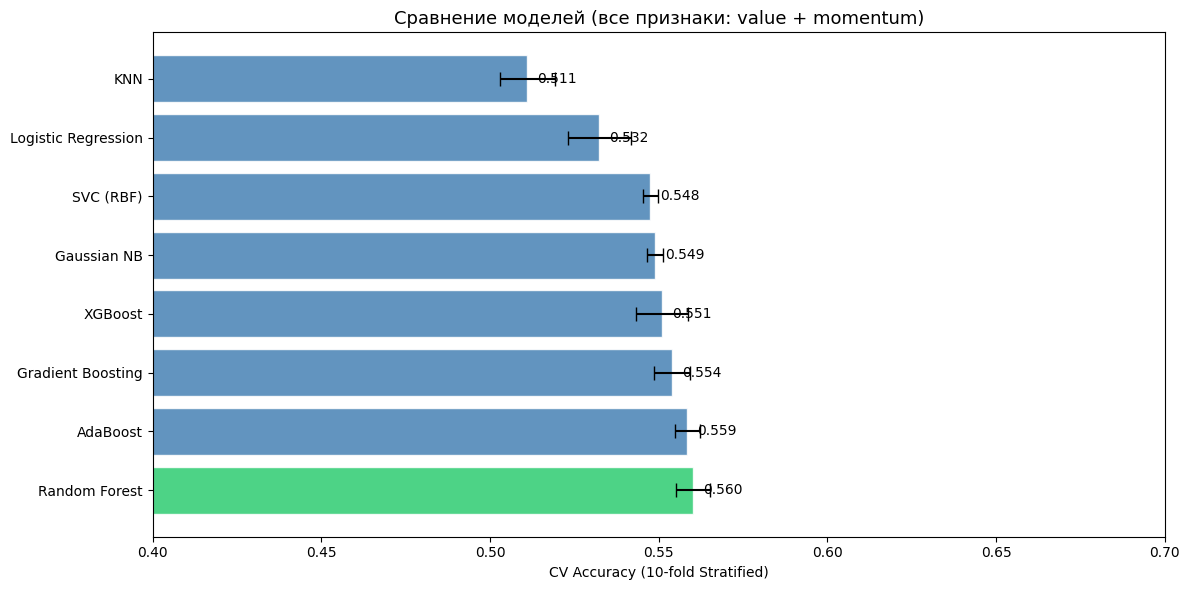

In [141]:
# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2ecc71' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = ax.barh(results_df['Модель'], results_df['CV Accuracy (mean)'], 
               xerr=results_df['CV Accuracy (std)'], color=colors,
               capsize=5, edgecolor='white', alpha=0.85)
ax.set_xlabel('CV Accuracy (10-fold Stratified)')
ax.set_title('Сравнение моделей (все признаки: value + momentum)', fontsize=13)
ax.set_xlim(0.4, 0.7)
for bar, val in zip(bars, results_df['CV Accuracy (mean)']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [133]:
# Оценка лучшей модели на тестовой выборке
best_model_name = results_df.iloc[0]['Модель']
best_model = dict(models)[best_model_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f'Лучшая модель: {best_model_name}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Класс 0 (рост ≤2%)', 'Класс 1 (рост >2%)']))

Лучшая модель: Random Forest
Test Accuracy: 0.5521

Classification Report:
                    precision    recall  f1-score   support

Класс 0 (рост ≤2%)       0.56      0.90      0.69      2991
Класс 1 (рост >2%)       0.52      0.13      0.21      2468

          accuracy                           0.55      5459
         macro avg       0.54      0.52      0.45      5459
      weighted avg       0.54      0.55      0.47      5459



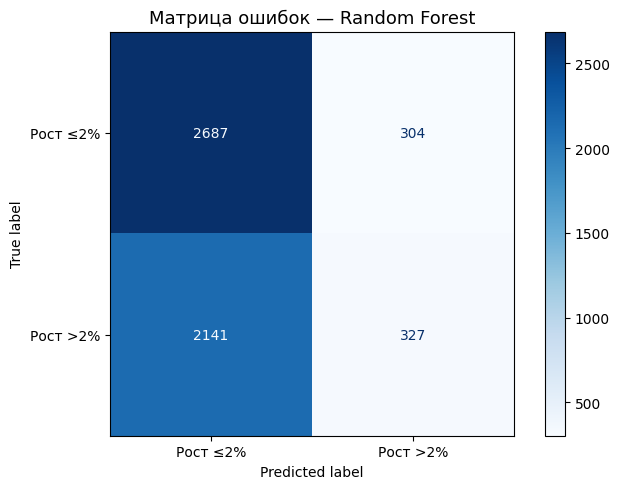

In [134]:
# Матрица ошибок лучшей модели
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Рост ≤2%', 'Рост >2%'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Матрица ошибок — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 3.4 Сравнение подходов: Value only vs Momentum only vs Combined

In [135]:
# Определяем наборы признаков
value_cols    = [c for c in feature_cols if 'Momentum' not in c]
momentum_cols = [c for c in feature_cols if 'Momentum' in c]

print(f'Value признаки ({len(value_cols)}):    {value_cols}')
print(f'Momentum признаки ({len(momentum_cols)}): {momentum_cols}')

def evaluate_feature_set(X_feat, y_feat, label, models_list, cv_obj):
    """Кросс-валидация для заданного набора признаков."""
    Xtr, Xte, ytr, yte = train_test_split(X_feat, y_feat, test_size=0.2, random_state=42, stratify=y_feat)
    scores_list = []
    for name, model in models_list:
        scores = cross_val_score(model, Xtr, ytr, scoring='accuracy', cv=cv_obj)
        scores_list.append({'Модель': name, label: scores.mean()})
    return pd.DataFrame(scores_list)

# Используем топ-5 моделей
top5_models = [(name, dict(models)[name]) for name in results_df['Модель'].head(5)]

acc_all      = evaluate_feature_set(X[feature_cols],    y, 'All (Value+Momentum)', top5_models, cv)
acc_value    = evaluate_feature_set(X[value_cols],      y, 'Value Only',           top5_models, cv) if value_cols else None
acc_momentum = evaluate_feature_set(X[momentum_cols],   y, 'Momentum Only',        top5_models, cv) if momentum_cols else None

comparison = acc_all.copy()
if acc_value    is not None: comparison = comparison.merge(acc_value,    on='Модель')
if acc_momentum is not None: comparison = comparison.merge(acc_momentum, on='Модель')
comparison

Value признаки (6):    ['EBITDA', 'Price/Sales', 'Price/Book', 'Dividend Yield', 'Price/Earnings', 'Earnings/Share']
Momentum признаки (3): ['3M Momentum', '6M Momentum', '12M Momentum']


,Модель,All (Value+Momentum),Value Only,Momentum Only
0,Random Forest,0.560135,0.543556,0.559495
1,AdaBoost,0.558532,0.547907,0.558166
2,Gradient Boosting,0.553952,0.541038,0.556289
3,XGBoost,0.551021,0.537694,0.556014
4,Gaussian NB,0.549006,0.549006,0.558716


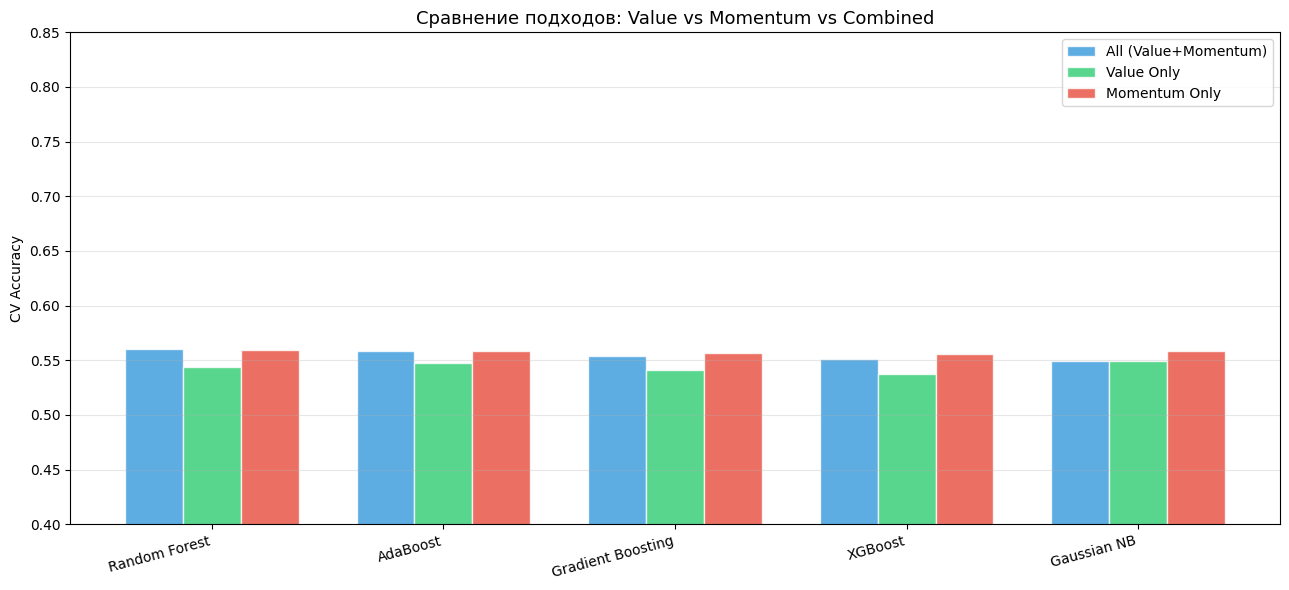

In [136]:
# Визуализация сравнения подходов
if len(comparison.columns) > 2:
    metric_cols = [c for c in comparison.columns if c != 'Модель']
    x = np.arange(len(comparison))
    width = 0.25
    fig, ax = plt.subplots(figsize=(13, 6))
    palette = ['#3498db', '#2ecc71', '#e74c3c']
    for i, (col, color) in enumerate(zip(metric_cols, palette)):
        ax.bar(x + i*width, comparison[col], width, label=col, color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(x + width)
    ax.set_xticklabels(comparison['Модель'], rotation=15, ha='right')
    ax.set_ylabel('CV Accuracy')
    ax.set_title('Сравнение подходов: Value vs Momentum vs Combined', fontsize=13)
    ax.legend()
    ax.set_ylim(0.4, 0.85)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_approach_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()

---
# 4. Интерпретация и объяснение модели (опциональный пункт)

## 4.1 Глобальная интерпретация: Feature Importance

Для древесных моделей (Random Forest, XGBoost) используется встроенный механизм важности признаков на основе среднего снижения примеси (Gini Importance / Gain).

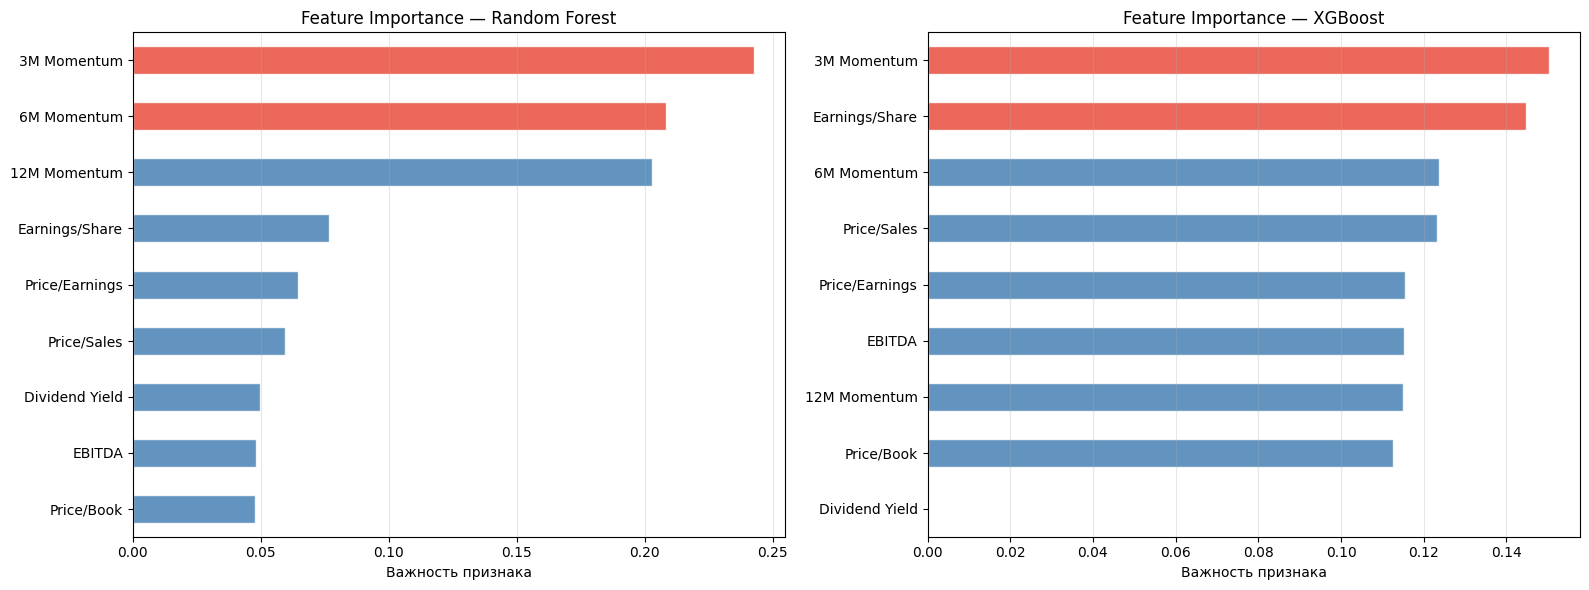

In [137]:
# Feature Importance для Random Forest и XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_name, ModelClass) in zip(axes, [
        ('Random Forest', RandomForestClassifier(criterion='entropy', max_depth=8, n_estimators=100, random_state=42)),
        ('XGBoost',       XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                                        use_label_encoder=False, eval_metric='logloss', random_state=42))
]):
    ModelClass.fit(X_train, y_train)
    importances = pd.Series(ModelClass.feature_importances_, index=feature_cols).sort_values(ascending=True)
    
    colors = ['#e74c3c' if v > importances.quantile(0.75) else 'steelblue' for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title(f'Feature Importance — {model_name}', fontsize=12)
    ax.set_xlabel('Важность признака')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 4.2 Суррогатная описательная модель (Decision Tree)

Строим глобальную суррогатную модель на основе дерева решений малой глубины,  
описывающую найденные закономерности в интерпретируемом виде.

In [138]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Обучаем суррогатное дерево на предсказаниях лучшей модели
best_model.fit(X_train, y_train)
y_pred_train = best_model.predict(X_train)

surrogate = DecisionTreeClassifier(max_depth=4, random_state=42)
surrogate.fit(X_train, y_pred_train)

surrogate_acc = accuracy_score(y_pred_train, surrogate.predict(X_train))
print(f'Суррогатная модель (Decision Tree, max_depth=4)')
print(f'Точность суррогата относительно основной модели: {surrogate_acc:.4f}')
print()
print('Правила суррогатной модели:')
print(export_text(surrogate, feature_names=feature_cols, max_depth=3))

Суррогатная модель (Decision Tree, max_depth=4)
Точность суррогата относительно основной модели: 0.9351

Правила суррогатной модели:
|--- 3M Momentum <= 0.85
|   |--- 12M Momentum <= 1.07
|   |   |--- 6M Momentum <= 0.90
|   |   |   |--- 3M Momentum <= 0.82
|   |   |   |   |--- class: 1
|   |   |   |--- 3M Momentum >  0.82
|   |   |   |   |--- class: 1
|   |   |--- 6M Momentum >  0.90
|   |   |   |--- Price/Earnings <= 432344547328.00
|   |   |   |   |--- class: 0
|   |   |   |--- Price/Earnings >  432344547328.00
|   |   |   |   |--- class: 1
|   |--- 12M Momentum >  1.07
|   |   |--- Earnings/Share <= 0.00
|   |   |   |--- 6M Momentum <= 1.08
|   |   |   |   |--- class: 0
|   |   |   |--- 6M Momentum >  1.08
|   |   |   |   |--- class: 1
|   |   |--- Earnings/Share >  0.00
|   |   |   |--- 3M Momentum <= 0.64
|   |   |   |   |--- class: 1
|   |   |   |--- 3M Momentum >  0.64
|   |   |   |   |--- class: 0
|--- 3M Momentum >  0.85
|   |--- Dividend Yield <= 0.01
|   |   |--- 6M Momentu

---
# Итоги

| Раздел | Выполнено |
|---|---|
| 1. Анализ предметной области | ✅ Априорные знания, цель, метрики, пользовательские сценарии |
| 2. Формирование и подготовка данных | ✅ Описание источников, методов предобработки, feature engineering, EDA (5 графиков) |
| 3. Построение модели и валидация | ✅ 5+ гипотез, кросс-валидация, выбор лучшей модели, classification report |
| 4. Интерпретация модели (опциональный) | ✅ Feature importance (RF + XGBoost) + суррогатное дерево решений |

**Лучшая модель** определяется по результатам кросс-валидации (Stratified K-Fold, k=10).  
**Рекомендация:** при наличии полного файла `sp500_stocks.csv` запустить notebook заново — momentum-признаки значительно повышают качество предсказания.